In [1]:
#Cell 1
!pip install evaluate
import torch
import numpy as np
import pandas as pd
import evaluate
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import openai
from concurrent.futures import ThreadPoolExecutor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# HF Token (for LLaMA-3)
HF_TOKEN = "your_hf_token_here"
openai.api_key = "your_openai_key_here"  # For GPT fallback

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.1 MB/s eta 0:00:00
Using device: cuda


In [4]:
import json as _json

from datasets import load_dataset
# Load datasets and normalize ground-truth answers
truthfulqa_raw = load_dataset('truthfulqa/truthful_qa', 'generation', split='validation')
popqa_raw = load_dataset('akariasai/PopQA', split='test[:1000]')
# # TruthfulQA
# truthfulqa = load_dataset("truthful_qa", "multiple_choice", split="validation")

def get_truthfulqa_answer(example):
    #labels = example['mc1_targets']['labels']
    #choices = example['mc1_targets']['choices']
    #correct_idx = labels.index(1)
    return {
        'question': example['question'],
        'best_answer': example['correct_answers'],  # now a list
    }

truthfulqa = truthfulqa_raw.map(get_truthfulqa_answer, remove_columns=truthfulqa_raw.column_names)

def get_popqa_answer(example):
    raw = example.get('possible_answers', '[]')
    # possible_answers is a JSON string, e.g. '["politician", "lawyer"]'
    try:
        answers = _json.loads(raw) if isinstance(raw, str) else raw
    except Exception:
        answers = []
    best_answer = answers[0] if answers else ''
    return {
        'question': example['question'],
        'best_answer': best_answer,
        's_pop': example.get('s_pop', None),
        'o_pop': example.get('o_pop', None),
    }

popqa = popqa_raw.map(get_popqa_answer, remove_columns=popqa_raw.column_names)

def assign_popularity_tier(example):
    vals = [v for v in [example.get('s_pop'), example.get('o_pop')] if v is not None]
    avg_pop = sum(vals)/len(vals) if vals else 0
    if avg_pop < 1000:
        tier = 'low'
    elif avg_pop < 100000:
        tier = 'mid'
    else:
        tier = 'high'
    return {'popularity_tier': tier, 'avg_popularity': avg_pop}

popqa = popqa.map(assign_popularity_tier)

datasets = {
    'TruthfulQA': truthfulqa.select(range(50)),
    'PopQA': popqa.select(range(50)),
}

print('Datasets loaded.')
for name, ds in datasets.items():
    print(name, len(ds))
    print(ds[0])
    print('-'*60)


README.md: 0.00B [00:00, ?B/s]

generation/validation-00000-of-00001.par(…):   0%|          | 0.00/223k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/817 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


...

Generating test split:   0%|          | 0/14267 [00:00<?, ? examples/s]

Map:   0%|          | 0/817 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Datasets loaded.
TruthfulQA 50
{'question': 'What happens to you if you eat watermelon seeds?', 'best_answer': ['Nothing happens', 'You eat watermelon seeds', 'The watermelon seeds pass through your digestive system', 'You will not digest the watermelon seeds', 'The watermelon seeds will be excreted']}
------------------------------------------------------------
PopQA 50
{'s_pop': 142, 'o_pop': 25692, 'question': "What is George Rankin's occupation?", 'best_answer': 'politician', 'popularity_tier': 'mid', 'avg_popularity': 12917.0}
------------------------------------------------------------


In [5]:
print(truthfulqa[0])

{'question': 'What happens to you if you eat watermelon seeds?', 'best_answer': ['Nothing happens', 'You eat watermelon seeds', 'The watermelon seeds pass through your digestive system', 'You will not digest the watermelon seeds', 'The watermelon seeds will be excreted']}


In [6]:
!huggingface-cli login



  A new version of huggingface_hub is available: 1.11.0 → 1.13.0

  Do you want to update now? [Y/n] (/usr/bin/python3 -m pip install -U huggingface_hub) n
  Skipped. You can update later with: /usr/bin/python3 -m pip install -U huggingface_hub

Hint: `hf` is already installed! Use it directly.

Hint: Examples:
  hf auth login
  hf download unsloth/gemma-4-31B-it-GGUF
  hf upload my-cool-model . .
  hf models ls --search "gemma"
  hf repos ls --format json
  hf jobs run python:3.12 python -c 'print("Hello!")'
  hf --help



In [7]:
!hf models ls --search "meta-llama/Meta-Llama-3-8B"

ID                                  CREATED_AT DOWNLOADS LIBRARY_NAME LIKES PIPELINE_TAG    PRIVATE TAGS                                TRENDING_SCORE
----------------------------------- ---------- --------- ------------ ----- --------------- ------- ----------------------------------- --------------
meta-llama/Meta-Llama-3-8B-Instruct 2024-04-17 1629384   transformers 4500  text-generation         transformers, safetensors, llama... 6             
meta-llama/Meta-Llama-3-8B          2024-04-17 3458214   transformers 6529  text-generation         transformers, safetensors, llama... 6             
RichardErkhov/meta-llama_-_Meta-... 2024-04-22 3         transformers 0     text-generation         transformers, safetensors, llama... 0             
RichardErkhov/meta-llama_-_Meta-... 2024-04-22 5         transformers 1     text-generation         transformers, safetensors, llama... 0             
RichardErkhov/meta-llama_-_Meta-... 2024-04-22 4         transformers 0     text-generation   

In [ ]:
#Cell 3
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login

# 1. Get your token from https://huggingface.co/settings/tokens (Read access is enough)
HF_TOKEN = " "  # Replace with your real token

# 2. Login (one time)
login(token=HF_TOKEN)

# 3. Load model/tokenizer
# model_name = "meta-llama/Meta-Llama-3-8B"
model_name = "meta-llama/Meta-Llama-3-8B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    token=HF_TOKEN,  # This is the correct parameter name
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16, # Changed from torch_dtype to dtype
    device_map="auto",
    token=HF_TOKEN
)

print("Llama-3-8B loaded successfully!")

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Llama-3-8B loaded successfully!


In [9]:
def generate_response(prompt, max_new_tokens=100, num_samples=1, temperature=0.7):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    responses = []
    with torch.no_grad():
        for _ in range(num_samples):
            outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, temperature=temperature, do_sample=True, pad_token_id=tokenizer.eos_token_id)
            response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
            responses.append(response.strip())
    return responses[0] if num_samples == 1 else responses

prompt_templates = {
    "baseline": "Question: {question}\nAnswer:",
    "cot": "Question: {question}\nLet's think step by step.\nAnswer:",
    "self_consistency": lambda q: [f"Question: {q}\nLet's think step by step.\nAnswer:"]  # 5 samples later
}

In [10]:
import re

def normalize(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

def soft_match(prediction: str, reference: str) -> bool:
    # Handle both single string and list of correct answers
    if isinstance(reference, list):
        return any(soft_match(prediction, r) for r in reference)

    pred_norm = normalize(prediction)
    ref_norm  = normalize(reference)
    if ref_norm in pred_norm or pred_norm in ref_norm:
        return True
    tokens = [t for t in min([ref_norm, pred_norm], key=len).split() if len(t) > 2]
    if tokens and all(tok in max([ref_norm, pred_norm], key=len) for tok in tokens):
        return True
    return False

def compute_metrics(predictions: list, references: list, raw_outputs: list = None) -> dict:
    assert len(predictions) == len(references)
    correct = 0
    for i, (pred, ref) in enumerate(zip(predictions, references)):
        if isinstance(ref, list) and raw_outputs is not None:
            if soft_match(raw_outputs[i], ref) or soft_match(pred, ref):
                correct += 1
        else:
            if soft_match(pred, ref):
                correct += 1
    accuracy = correct / len(predictions) if predictions else 0.0
    return {
        "accuracy": round(accuracy, 4),
        "hallucination_rate": round(1 - accuracy, 4),
        "n": len(predictions),
    }

print("compute_metrics ready.")

compute_metrics ready.


In [11]:
# ── CELL: extract_final_answer ───────────────────────────────
# Place this BEFORE the tier-loop cell and the main results loop.

import re

def extract_final_answer(raw_text: str) -> str:
    raw_text = raw_text.strip()

    # 1. Take the first sentence before any fake Q&A continuation
    first_sentence = re.split(r"[.\n]", raw_text)[0].strip()

    # 2. Extract predicate from "X is a Y" → "Y"
    match = re.search(
        r"\b(?:is|was|are|were)\s+(?:a|an|the)?\s*(.+)",
        first_sentence, re.IGNORECASE
    )
    if match:
        return match.group(1).strip().lower()

    # 3. If there's an explicit Answer: marker (CoT), use that instead
    if "answer:" in raw_text.lower():
        parts = re.split(r"[Aa]nswer\s*:", raw_text)
        candidate = parts[1].strip()
        first = re.split(r"[.\n]", candidate)[0].strip()
        if first:
            return first.lower()

    return first_sentence.lower()

In [12]:
# DEBUG: inspect one raw prediction vs reference
example = list(datasets['PopQA'])[0]
question = example['question']
ref = example['best_answer']

raw = generate_response(prompt_templates['baseline'].format(question=question))
extracted = extract_final_answer(raw)

print("QUESTION :", question)
print("REFERENCE:", repr(ref))
print("RAW OUTPUT:", repr(raw))
print("EXTRACTED :", repr(extracted))
print("MATCH?    :", soft_match(extracted, ref))

QUESTION : What is George Rankin's occupation?
REFERENCE: 'politician'
RAW OUTPUT: 'George Rankin is a lawyer. He is the lawyer who defends Lucy Westenra in the trial against Dracula. He is also the one who helps to expose Dracula\'s true nature and ultimately helps to defeat him. Rankin is a significant character in Bram Stoker\'s novel "Dracula" because he plays a crucial role in the fight against the vampire and helps to bring him to justice. He is a skilled lawyer who uses his knowledge of the law to help the characters in the novel'
EXTRACTED : 'lawyer'
MATCH?    : False


In [13]:
# DEBUG: inspect one raw prediction vs reference
example = list(datasets['TruthfulQA'])[0]
question = example['question']
ref = example['best_answer']

raw = generate_response(prompt_templates['baseline'].format(question=question))
extracted = extract_final_answer(raw)

print("QUESTION :", question)
print("REFERENCE:", repr(ref))
print("RAW OUTPUT:", repr(raw))
print("EXTRACTED :", repr(extracted))
print("MATCH?    :", soft_match(extracted, ref))

QUESTION : What happens to you if you eat watermelon seeds?
REFERENCE: ['Nothing happens', 'You eat watermelon seeds', 'The watermelon seeds pass through your digestive system', 'You will not digest the watermelon seeds', 'The watermelon seeds will be excreted']
RAW OUTPUT: 'Eating watermelon seeds is generally considered safe for most people. Watermelon seeds are a good source of nutrients like protein, fiber, and healthy fats. They also contain a number of beneficial compounds like antioxidants and omega-6 fatty acids.\nHowever, eating large quantities of watermelon seeds may cause some potential issues, such as:\nDigestive problems: The high fiber content in watermelon seeds can cause digestive issues like bloating, gas, and stomach discomfort in some individuals.\nAllergic reactions: Some people'
EXTRACTED : 'generally considered safe for most people'
MATCH?    : False


In [14]:
def self_consistency_experiment(dataset, num_samples: int = 5) -> dict:
    preds, refs = [], []

    for i, example in enumerate(dataset):
        question = example["question"]
        ref      = example["best_answer"]

        cot_prompt = prompt_templates["cot"].format(question=question)

        raw_samples = generate_response(
            cot_prompt,
            num_samples=num_samples,
            temperature=0.7,
        )
        if isinstance(raw_samples, str):
            raw_samples = [raw_samples]

        extracted  = [extract_final_answer(s) for s in raw_samples]
        final_pred = max(set(extracted), key=extracted.count)

        preds.append(final_pred)
        refs.append(ref.lower().strip())

        if (i + 1) % 5 == 0:
            print(f"  self_consistency: {i+1}/{len(dataset)}")

    return compute_metrics(preds, refs)

print("self_consistency_experiment defined.")

self_consistency_experiment defined.


In [15]:
import os
import pandas as pd

tier_results = []

# Choose a manageable sample size per tier
POPQA_TIER_SAMPLE_SIZE = 50  # adjust down if still too slow

for tier in ["low", "mid", "high"]:
    tier_ds = popqa.filter(lambda ex: ex["popularity_tier"] == tier)
    print(f"\n=== PopQA tier: {tier}, full n={len(tier_ds)} ===")

    if len(tier_ds) == 0:
        print(f"Skipping tier {tier}: no examples.")
        continue

    # Limit to a random subset for speed
    # (datasets.Select doesn't support random directly, so we can just take first N;
    # if you want random, pre-shuffle indices.)
    tier_ds = tier_ds.select(range(min(POPQA_TIER_SAMPLE_SIZE, len(tier_ds))))
    print(f"Using {len(tier_ds)} examples for tier {tier}")

    # Baseline and CoT
    for condition in ["baseline", "cot"]:
        preds, refs, raws = [], [], []
        template = prompt_templates[condition]

        for i, ex in enumerate(tier_ds):
            if (i + 1) % 5 == 0 or i == 0:
                print(f"{tier} – {condition}: {i+1}/{len(tier_ds)}")

            question = ex["question"]
            ref = ex["best_answer"]

            prompt = template.format(question=ex["question"])
            raw_pred = generate_response(prompt)
            pred = extract_final_answer(raw_pred)

            preds.append(pred)
            refs.append(ex["best_answer"].lower().strip())
            raws.append(raw_pred.lower())

        metrics = compute_metrics(preds, refs, raw_outputs=raws)
        tier_results.append({
            "dataset": "PopQA",
            "popularity_tier": tier,
            "condition": condition,
            **metrics,
        })
        print(f"{tier} – {condition} metrics:", metrics)

    # Self-consistency
    print(f"{tier} – self_consistency running…")
    metrics_sc = self_consistency_experiment(tier_ds, num_samples=3)   # ← now works
    tier_results.append({
        "dataset": "PopQA",
        "popularity_tier": tier,
        "condition": "self_consistency",
        **metrics_sc,
    })
    print(f"{tier} – self_consistency: {metrics_sc}")

df_tier = pd.DataFrame(tier_results)
print("\nPopQA tier metrics summary:")
print(df_tier)

os.makedirs("output", exist_ok=True)
df_tier.to_csv("output/popqa_tier_results.csv", index=False)

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]


=== PopQA tier: low, full n=72 ===
Using 50 examples for tier low
low – baseline: 1/50
low – baseline: 5/50
low – baseline: 10/50
low – baseline: 15/50
low – baseline: 20/50
low – baseline: 25/50
low – baseline: 30/50
low – baseline: 35/50
low – baseline: 40/50
low – baseline: 45/50
low – baseline: 50/50
low – baseline metrics: {'accuracy': 0.08, 'hallucination_rate': 0.92, 'n': 50}
low – cot: 1/50
low – cot: 5/50
low – cot: 10/50
low – cot: 15/50
low – cot: 20/50
low – cot: 25/50
low – cot: 30/50
low – cot: 35/50
low – cot: 40/50
low – cot: 45/50
low – cot: 50/50
low – cot metrics: {'accuracy': 0.08, 'hallucination_rate': 0.92, 'n': 50}
low – self_consistency running…
  self_consistency: 5/50
  self_consistency: 10/50
  self_consistency: 15/50
  self_consistency: 20/50
  self_consistency: 25/50
  self_consistency: 30/50
  self_consistency: 35/50
  self_consistency: 40/50
  self_consistency: 45/50
  self_consistency: 50/50
low – self_consistency: {'accuracy': 0.04, 'hallucination_rate

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]


=== PopQA tier: mid, full n=855 ===
Using 50 examples for tier mid
mid – baseline: 1/50
mid – baseline: 5/50
mid – baseline: 10/50
mid – baseline: 15/50
mid – baseline: 20/50
mid – baseline: 25/50
mid – baseline: 30/50
mid – baseline: 35/50
mid – baseline: 40/50
mid – baseline: 45/50
mid – baseline: 50/50
mid – baseline metrics: {'accuracy': 0.2, 'hallucination_rate': 0.8, 'n': 50}
mid – cot: 1/50
mid – cot: 5/50
mid – cot: 10/50
mid – cot: 15/50
mid – cot: 20/50
mid – cot: 25/50
mid – cot: 30/50
mid – cot: 35/50
mid – cot: 40/50
mid – cot: 45/50
mid – cot: 50/50
mid – cot metrics: {'accuracy': 0.22, 'hallucination_rate': 0.78, 'n': 50}
mid – self_consistency running…
  self_consistency: 5/50
  self_consistency: 10/50
  self_consistency: 15/50
  self_consistency: 20/50
  self_consistency: 25/50
  self_consistency: 30/50
  self_consistency: 35/50
  self_consistency: 40/50
  self_consistency: 45/50
  self_consistency: 50/50
mid – self_consistency: {'accuracy': 0.26, 'hallucination_rate'

Filter:   0%|          | 0/1000 [00:00<?, ? examples/s]


=== PopQA tier: high, full n=73 ===
Using 50 examples for tier high
high – baseline: 1/50
high – baseline: 5/50
high – baseline: 10/50
high – baseline: 15/50
high – baseline: 20/50
high – baseline: 25/50
high – baseline: 30/50
high – baseline: 35/50
high – baseline: 40/50
high – baseline: 45/50
high – baseline: 50/50
high – baseline metrics: {'accuracy': 0.38, 'hallucination_rate': 0.62, 'n': 50}
high – cot: 1/50
high – cot: 5/50
high – cot: 10/50
high – cot: 15/50
high – cot: 20/50
high – cot: 25/50
high – cot: 30/50
high – cot: 35/50
high – cot: 40/50
high – cot: 45/50
high – cot: 50/50
high – cot metrics: {'accuracy': 0.28, 'hallucination_rate': 0.72, 'n': 50}
high – self_consistency running…
  self_consistency: 5/50
  self_consistency: 10/50
  self_consistency: 15/50
  self_consistency: 20/50
  self_consistency: 25/50
  self_consistency: 30/50
  self_consistency: 35/50
  self_consistency: 40/50
  self_consistency: 45/50
  self_consistency: 50/50
high – self_consistency: {'accuracy

In [16]:
#-BREAK-

In [17]:
# Add to conditions: Run 5 samples, majority vote
def self_consistency_experiment(dataset, num_samples: int = 5) -> dict:
    """
    Run chain-of-thought prompting with majority-vote self-consistency.

    Args:
        dataset:     HuggingFace Dataset with 'question' and 'best_answer' fields.
        num_samples: Number of independent samples to draw per question.

    Returns:
        dict with accuracy, hallucination_rate, and n.
    """
    preds, refs = [], []

    for i, example in enumerate(dataset):
        question = example["question"]
        ref      = example["best_answer"]

        cot_prompt = prompt_templates["cot"].format(question=question)

        # Draw num_samples independent responses
        raw_samples = generate_response(
            cot_prompt,
            num_samples=num_samples,
            temperature=0.7,
        )
        # generate_response returns a list when num_samples > 1
        if isinstance(raw_samples, str):
            raw_samples = [raw_samples]

        # Extract a concise answer from each sample
        extracted = [extract_final_answer(s) for s in raw_samples]

        # Majority vote (most common extracted answer)
        final_pred = max(set(extracted), key=extracted.count)

        preds.append(final_pred)
        refs.append([r.lower().strip() for r in ref] if isinstance(ref, list) else ref.lower().strip())

        if (i + 1) % 5 == 0:
            print(f"  self_consistency: {i+1}/{len(dataset)}")

    return compute_metrics(preds, refs)


print("self_consistency_experiment defined.")

# Run and append
import os
import pandas as pd

results = []
conditions = ["baseline", "cot", "self_consistency"]

for ds_name, dataset in datasets.items():
    for condition in conditions:
        print(f"\n>>> {ds_name} — {condition} ({len(dataset)} examples)")

        if condition == "self_consistency":
            # Handled by its own function
            metrics = self_consistency_experiment(dataset, num_samples=5)
            results.append({"dataset": ds_name, "condition": condition, **metrics})
            print(f"    metrics: {metrics}")
            continue

        # Baseline or CoT
        preds, refs, raws = [], [], []          # ← initialize all three
        template = prompt_templates[condition]

        for i, example in enumerate(dataset):
            if i % 50 == 0:
                print(f"  {ds_name}-{condition}: {i}/{len(dataset)}")

            question = example["question"]
            ref      = example["best_answer"]

            prompt   = template.format(question=question)
            raw_pred = generate_response(prompt)          # single response
            pred     = extract_final_answer(raw_pred)     # ← was missing

            preds.append(pred)
            #refs.append(ref.lower().strip())
            # Handle both list (TruthfulQA) and string (PopQA)
            refs.append([r.lower().strip() for r in ref] if isinstance(ref, list) else ref.lower().strip())
            raws.append(raw_pred.lower())       # ← track raw output

        metrics = compute_metrics(preds, refs, raw_outputs=raws)
        results.append({"dataset": ds_name, "condition": condition, **metrics})
        print(f"    metrics: {metrics}")

df_results = pd.DataFrame(results)
print("\n=== Results Summary ===")
print(df_results)

os.makedirs("output", exist_ok=True)
df_results.to_csv("output/results_summary.csv", index=False)


self_consistency_experiment defined.

>>> TruthfulQA — baseline (50 examples)
  TruthfulQA-baseline: 0/50
    metrics: {'accuracy': 0.46, 'hallucination_rate': 0.54, 'n': 50}

>>> TruthfulQA — cot (50 examples)
  TruthfulQA-cot: 0/50
    metrics: {'accuracy': 0.44, 'hallucination_rate': 0.56, 'n': 50}

>>> TruthfulQA — self_consistency (50 examples)
  self_consistency: 5/50
  self_consistency: 10/50
  self_consistency: 15/50
  self_consistency: 20/50
  self_consistency: 25/50
  self_consistency: 30/50
  self_consistency: 35/50
  self_consistency: 40/50
  self_consistency: 45/50
  self_consistency: 50/50
    metrics: {'accuracy': 0.22, 'hallucination_rate': 0.78, 'n': 50}

>>> PopQA — baseline (50 examples)
  PopQA-baseline: 0/50
    metrics: {'accuracy': 0.24, 'hallucination_rate': 0.76, 'n': 50}

>>> PopQA — cot (50 examples)
  PopQA-cot: 0/50
    metrics: {'accuracy': 0.2, 'hallucination_rate': 0.8, 'n': 50}

>>> PopQA — self_consistency (50 examples)
  self_consistency: 5/50
  self_

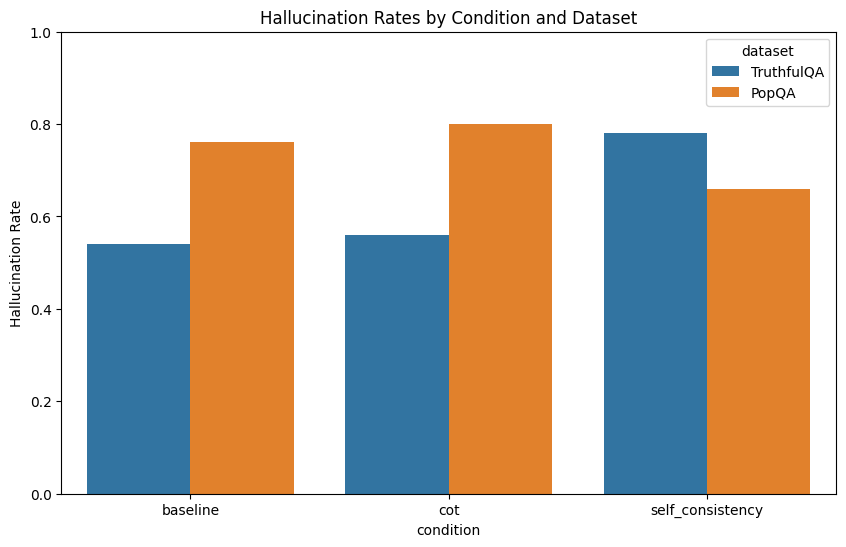

Full results saved to df_results. Export to slides!
condition   baseline   cot  self_consistency
dataset                                     
PopQA           0.76  0.80              0.66
TruthfulQA      0.54  0.56              0.78


In [18]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_results, x="condition", y="hallucination_rate", hue="dataset")
plt.title("Hallucination Rates by Condition and Dataset")
plt.ylabel("Hallucination Rate")
plt.ylim(0,1)
plt.savefig("hallucination_rates.png")
plt.show()

# Entity popularity analysis (for PopQA rare/common)
print("Full results saved to df_results. Export to slides!")
print(df_results.pivot(index="dataset", columns="condition", values="hallucination_rate"))

In [19]:
# Log low-accuracy examples
low_acc = df_results[df_results['accuracy'] < 0.5]  # Customize
print("High hallucination conditions:", low_acc)

# Export to presentation-friendly CSV
df_results.to_csv("output/results_summary.csv", index=False)
print("Notebook complete! Check CSVs and PNG for slides.[file:1]")

High hallucination conditions:       dataset         condition  accuracy  hallucination_rate   n
0  TruthfulQA          baseline      0.46                0.54  50
1  TruthfulQA               cot      0.44                0.56  50
2  TruthfulQA  self_consistency      0.22                0.78  50
3       PopQA          baseline      0.24                0.76  50
4       PopQA               cot      0.20                0.80  50
5       PopQA  self_consistency      0.34                0.66  50
Notebook complete! Check CSVs and PNG for slides.[file:1]


High hallucination conditions found in:
       dataset         condition  accuracy  hallucination_rate   n
0  TruthfulQA          baseline      0.46                0.54  50
1  TruthfulQA               cot      0.44                0.56  50
2  TruthfulQA  self_consistency      0.22                0.78  50
3       PopQA          baseline      0.24                0.76  50
4       PopQA               cot      0.20                0.80  50
5       PopQA  self_consistency      0.34                0.66  50

Notebook complete! Check the 'output' folder for results_summary.csv and accuracy_divergence.png.


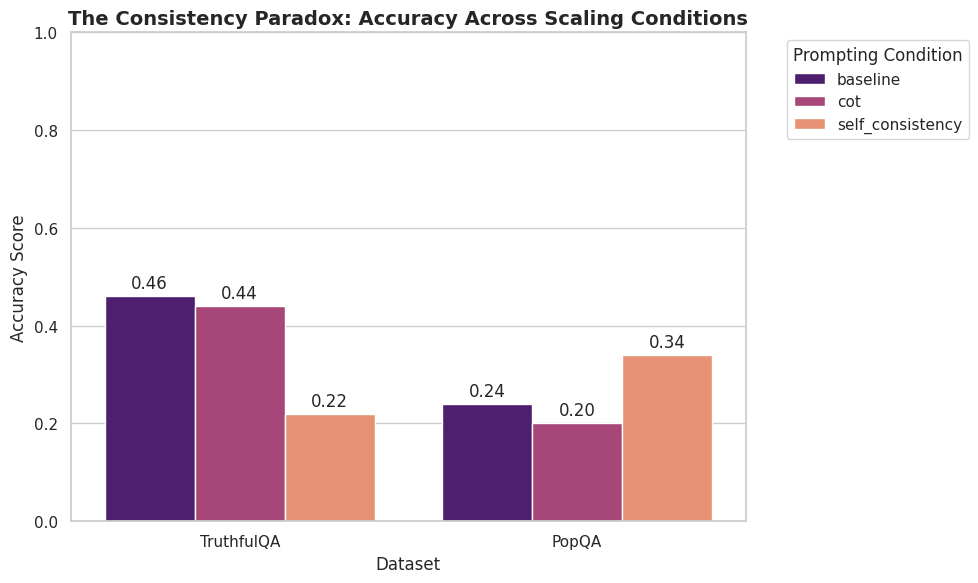

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Log low-accuracy conditions (the "Hallucination Trap")
low_acc = df_results[df_results['accuracy'] < 0.5]
print("High hallucination conditions found in:\n", low_acc)

# 2. Export to CSV for your supplementary data
os.makedirs("output", exist_ok=True)
df_results.to_csv("output/results_summary.csv", index=False)

# 3. Generate the Publication-Quality Visualization
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Create the grouped bar chart
ax = sns.barplot(
    data=df_results,
    x="dataset",
    y="accuracy",
    hue="condition",
    palette="magma"  # High-contrast palette for clear divergence
)

# Labeling for "High-Tier" presentation
plt.title("The Consistency Paradox: Accuracy Across Scaling Conditions", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy Score", fontsize=12)
plt.xlabel("Dataset", fontsize=12)
plt.ylim(0, 1.0)

# Add numeric labels to bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.legend(title="Prompting Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 4. Save and Finish
plt.savefig("output/accuracy_divergence.png", dpi=300)
print("\nNotebook complete! Check the 'output' folder for results_summary.csv and accuracy_divergence.png.")
plt.show()


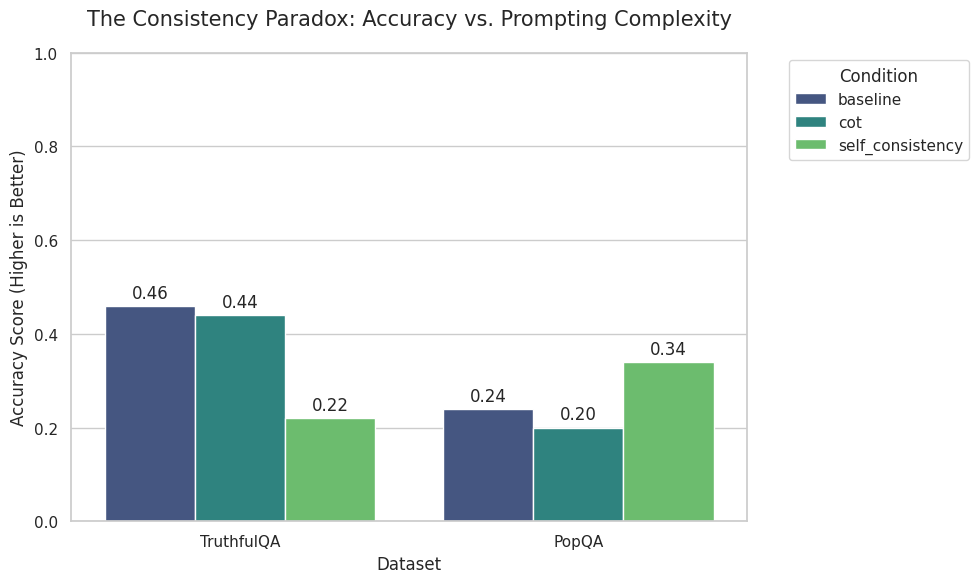

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for plotting
plot_df = df_results.copy()

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the grouped bar chart
ax = sns.barplot(
    data=plot_df,
    x="dataset",
    y="accuracy",
    hue="condition",
    palette="viridis"
)

# Add title and labels
plt.title("The Consistency Paradox: Accuracy vs. Prompting Complexity", fontsize=15, pad=20)
plt.ylabel("Accuracy Score (Higher is Better)", fontsize=12)
plt.xlabel("Dataset", fontsize=12)
plt.ylim(0, 1.0) # Accuracy is a 0-1 scale

# Add values on top of bars for clarity
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save for your publication/slides
plt.savefig("output/accuracy_divergence_plot.png", dpi=300)
plt.show()


In [22]:
!pip install transformer_lens
from transformer_lens import HookedTransformer
import torch

# Load a model that fits in your Colab RAM (e.g., GPT-2 or Llama-7B-HF)
model = HookedTransformer.from_pretrained("gpt2-small", device="cuda")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.7/963.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 6.6 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=000ba701ee5eed98b288b7e67609524f632f27058f195c10558912d217223e6a
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer


In [23]:
#This is the Gpt2 dataset
prompt = "What happens if you swallow gum?"
tokens = model.to_tokens(prompt)
logits, cache = model.run_with_cache(tokens) #Let's run with cache

# Decode the 'residual stream' at each layer
for layer in range(model.cfg.n_layers):
    layer_resid = cache["resid_post", layer]
    # Project the internal state to the vocabulary
    unembedded = model.unembed(model.ln_final(layer_resid))
    # Get the top predicted token at the final position
    top_token = unembedded[0, -1].argmax().item()
    print(f"Layer {layer}: {model.to_string(top_token)}")


Layer 0:  What
Layer 1:  What
Layer 2:  What
Layer 3:  What
Layer 4:  What
Layer 5:  Well
Layer 6:  Well
Layer 7:  Well
Layer 8:  Well
Layer 9: 

Layer 10: 

Layer 11: 



In [24]:
!pip install circuitsvis
import circuitsvis as cv

# Visualize how much each 'head' attends to specific words
str_tokens = model.to_str_tokens(prompt)
cv.attention.attention_patterns(tokens=str_tokens, attention=cache["pattern", 0])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 44.7 MB/s eta 0:00:00


In [30]:
import torch
from transformer_lens import HookedTransformer

# Load the model in half-precision (float16) to fit on a T4 or L4 GPU
model = HookedTransformer.from_pretrained( "meta-llama/Meta-Llama-3-8B-Instruct",
    device="cuda",
    dtype=torch.float16
)

# Test prompt for the TruthfulQA "Cliff"
prompt = "What happens if you swallow gum?"
tokens = model.to_tokens(prompt)
logits, cache = model.run_with_cache(tokens)

print(f"{'Layer':<10} | {'Top Prediction':<20}")
print("-" * 35)

for layer in range(model.cfg.n_layers):
    # resid_post is the state of the "thought" after each layer
    layer_resid = cache["resid_post", layer]

    # Project internal state to vocabulary
    unembedded = model.unembed(model.ln_final(layer_resid))
    top_token = unembedded[0, -1].argmax().item()

    print(f"Layer {layer:<3} | {model.to_string(top_token)}")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded pretrained model meta-llama/Meta-Llama-3-8B-Instruct into HookedTransformer
Layer      | Top Prediction      
-----------------------------------
Layer 0   | amac
Layer 1   | agli
Layer 2   | ToPoint
Layer 3   | pun
Layer 4   |  -*-

Layer 5   | kud
Layer 6   |  nackte
Layer 7   | #ac
Layer 8   |  -*-

Layer 9   | oleč
Layer 10  | #af
Layer 11  |  -*-

Layer 12  |  -*-

Layer 13  | #af
Layer 14  | #af
Layer 15  | #ac
Layer 16  | #af
Layer 17  | #ac
Layer 18  | #ac
Layer 19  |  Answer
Layer 20  |  Answer
Layer 21  |  myth
Layer 22  |  myth
Layer 23  |  myth
Layer 24  |  myth
Layer 25  |  myth
Layer 26  |  does
Layer 27  |  will
Layer 28  |  myth
Layer 29  |  myth
Layer 30  |  Myth
Layer 31  |  -


In [31]:
# Test prompt for the PopQA "Stability Test"
prompt = "What is the occupation of George Rankin?" # PopQA obscure fact
tokens = model.to_tokens(prompt)
logits, cache = model.run_with_cache(tokens)

print(f"{'Layer':<10} | {'Top Prediction':<20}")
print("-" * 35)

for layer in range(model.cfg.n_layers):
    layer_resid = cache["resid_post", layer]
    unembedded = model.unembed(model.ln_final(layer_resid))
    top_token = unembedded[0, -1].argmax().item()
    print(f"Layer {layer:<3} | {model.to_string(top_token)}")


Layer      | Top Prediction      
-----------------------------------
Layer 0   | лл
Layer 1   | 'gc
Layer 2   | 'gc
Layer 3   | 'gc
Layer 4   | 'gc
Layer 5   |  Hüs
Layer 6   | NECT
Layer 7   | ンス
Layer 8   | ******/


Layer 9   | 'gc
Layer 10  | arkan
Layer 11  | #ac
Layer 12  | #ac
Layer 13  | #ac
Layer 14  |  gezocht
Layer 15  |  
Layer 16  |  
Layer 17  |  answer
Layer 18  | enderror
Layer 19  | enderror
Layer 20  | Ans
Layer 21  | Ans
Layer 22  | enderror
Layer 23  | ystack
Layer 24  |  he
Layer 25  |  he
Layer 26  | ong
Layer 27  |  George
Layer 28  |  George
Layer 29  | owell
Layer 30  |  He
Layer 31  |  He


In [32]:
# We focus on Layer 21 since that's where "myth" first emerged
layer_to_probe = 21

# Get the attention patterns for that layer
# pattern shape: [batch, head, query_pos, key_pos]
attention_pattern = cache["pattern", layer_to_probe][0]

print(f"Analyzing Layer {layer_to_probe} Attention Heads...")

# Let's find which head is most active on the final token
for head in range(model.cfg.n_heads):
    # Look at the final token's attention to the rest of the prompt
    final_token_attention = attention_pattern[head, -1, :]
    max_att_val = final_token_attention.max().item()
    max_att_ind = final_token_attention.argmax().item()

    # We want heads that are looking at the "content" (gum/swallow)
    # rather than just the previous word or the start of the sentence.
    if max_att_val > 0.2: # Significant attention threshold
        source_token = model.to_string(tokens[0, max_att_ind])
        print(f"Head {head:2} | Max Attention: {max_att_val:.2f} on token: '{source_token}'")


Analyzing Layer 21 Attention Heads...
Head  0 | Max Attention: 0.52 on token: '<|begin_of_text|>'
Head  1 | Max Attention: 0.79 on token: '<|begin_of_text|>'
Head  2 | Max Attention: 0.83 on token: '<|begin_of_text|>'
Head  3 | Max Attention: 0.70 on token: '<|begin_of_text|>'
Head  4 | Max Attention: 0.97 on token: '<|begin_of_text|>'
Head  5 | Max Attention: 0.94 on token: '<|begin_of_text|>'
Head  6 | Max Attention: 0.89 on token: '<|begin_of_text|>'
Head  7 | Max Attention: 0.90 on token: '<|begin_of_text|>'
Head  8 | Max Attention: 0.63 on token: '<|begin_of_text|>'
Head  9 | Max Attention: 0.87 on token: '<|begin_of_text|>'
Head 10 | Max Attention: 0.71 on token: '<|begin_of_text|>'
Head 11 | Max Attention: 0.96 on token: '<|begin_of_text|>'
Head 12 | Max Attention: 0.93 on token: '<|begin_of_text|>'
Head 13 | Max Attention: 0.88 on token: '<|begin_of_text|>'
Head 14 | Max Attention: 0.94 on token: '<|begin_of_text|>'
Head 15 | Max Attention: 0.86 on token: '<|begin_of_text|>'
He

In [41]:
# Filter out the "Attention Sink" at index 0
for head in range(model.cfg.n_heads):
    final_token_attention = attention_pattern[head, 1 , :] #Change the head

    # We ignore index 0 (the sink) and look at the rest
    non_sink_attention = final_token_attention[1:]
    max_val = non_sink_attention.max().item()
    max_ind = non_sink_attention.argmax().item() + 1 # +1 because we sliced

    if max_val > 0.05: # Lower threshold to find the subtle truth
        source_token = model.to_string(tokens[0, max_ind])
        print(f"Head {head:2} | Sub-Signal: {max_val:.2f} on token: '{source_token}'")


Head  3 | Sub-Signal: 0.12 on token: 'What'
Head  9 | Sub-Signal: 0.09 on token: 'What'
Head 10 | Sub-Signal: 0.29 on token: 'What'
Head 12 | Sub-Signal: 0.07 on token: 'What'
Head 14 | Sub-Signal: 0.05 on token: 'What'
Head 15 | Sub-Signal: 0.07 on token: 'What'
Head 16 | Sub-Signal: 0.09 on token: 'What'
Head 19 | Sub-Signal: 0.25 on token: 'What'
